In [30]:
# Import libraries for data manipulation
import pandas as pd

import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt

import seaborn as sns

from statsmodels.graphics.gofplots import ProbPlot

# Import libraries for building linear regression model
from statsmodels.formula.api import ols

import statsmodels.api as sm

from sklearn.linear_model import LinearRegression

# Import library for data preprocessing
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

In [31]:
dataset = pd.read_csv(r"/home/satyajit-sahoo/Downloads/BostonHousing.csv")
dataset.head(4)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4


In [32]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [44]:
dataset.shape

(506, 13)

In [33]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [34]:
# Observations:

# CRIM: Per capita crime rate by town
        # Around 75% of the crime rate falls between ~0-4, with a max of 88, suggesting a possible outlier
# ZN: Proportion of residential land zoned for lots over 25,000 sq.ft.
        # Over 50% have 0% have residential land zoned for lots over 25,00sq.ft with the max 100%, suggesting this is perhaps a rare commodity.
# INDUS: Proportion of non-retail business acres per town
        # Ranges from 0.4-27% with an average of 11%, suggesting most towns have some industrial businesses.
# CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        # With a mean of 0.069 only ~7% of houses bound the Charles River.
# NOX: Nitric Oxide concentration (parts per 10 million)
        # Ranges from 0.38-0.87 with an average of 0.55. The distribution looks nominal.
# RM: The average number of rooms per dwelling
        # Ranges from 3.5-8.7 with an average of 6.2. The distribution looks nominal.
# AGE: Proportion of owner-occupied units built before 1940
        # Ranges from 2.9-100y with an averaga of 68y. Distribution looks nominal.
        # Minimum age of 2.9y indicates that no houses in the database are newly built
# DIS: Weighted distances to five Boston employment centers
        # Ranges form 1.1-12.1 with an average of 3.7. Distribution looks nominal.
# RAD: Index of accessibility to radial highways
        # Ranges from 1-24 with over 75% being the max 24.
        # There is a large jump from the 50th percentile (5) and 75th percentile (24). Speculating that perhaps there are 2 categories of houses, those in rural areas and those in more urban.
# TAX: Full-value property tax rate per 10,000 dollars
        # Ranges from 187-711 with an average of 408. Distribution looks nominal.
        # That range suggests these are mid to high-income houses.
# PTRATIO: Pupil-teacher ratio by town
        # Ranges from 12.6-22 with an average of 18.4. The distribution looks nominal.
# LSTAT: % lower status of the population
        # Ranges from 7-37.9% with an average of 12%. This indicates that most areas have little lower socio-economic class.
        # The jump from 75th percentile (16.9%) to the max (37%) is indicative of a lower socio-economic area, or less likely an outlier
# MEDV: Median value of owner-occupied homes in 1000 dollars
        # Ranges from 5k-50k with an average of 22. The distribution looks nominal.

In [35]:
input_data = dataset.iloc[:,:-1]
input_data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48


In [36]:
output_data = dataset["MEDV"]
output_data

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

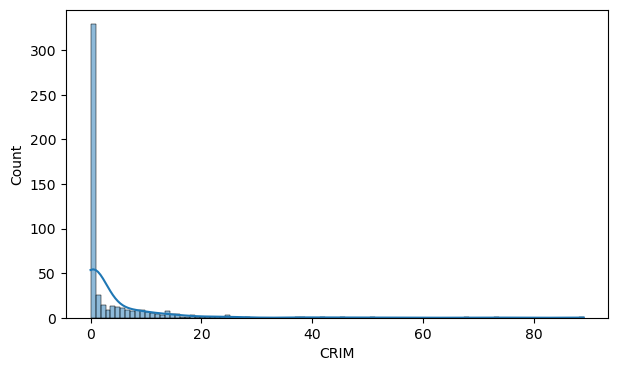

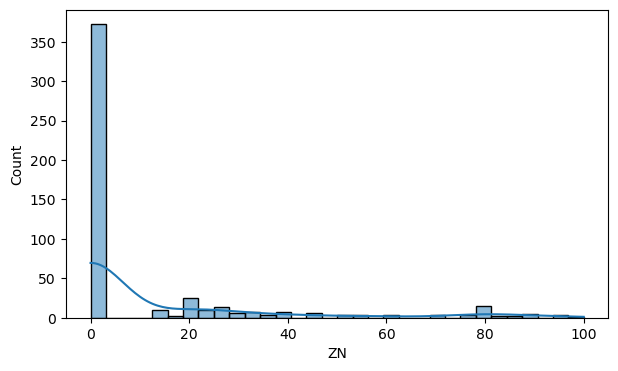

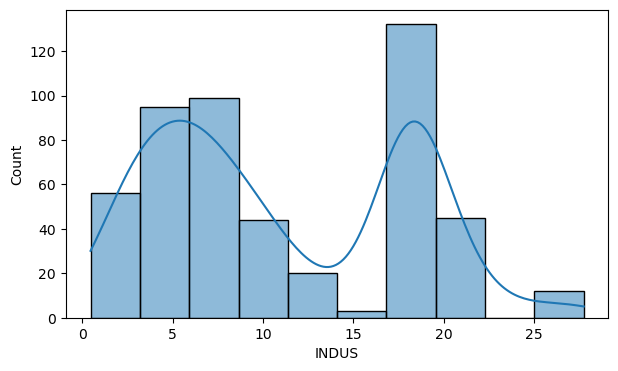

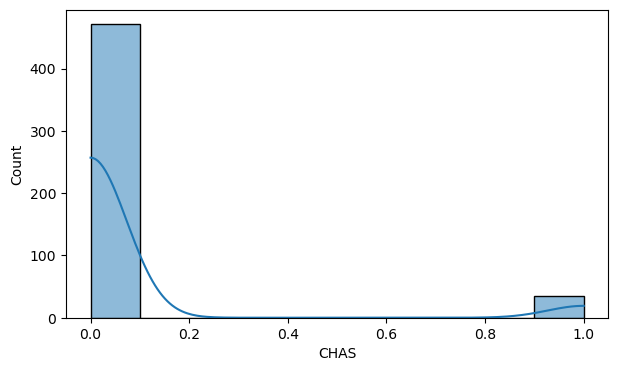

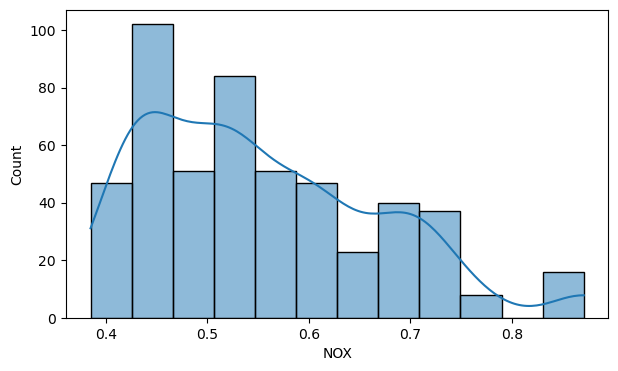

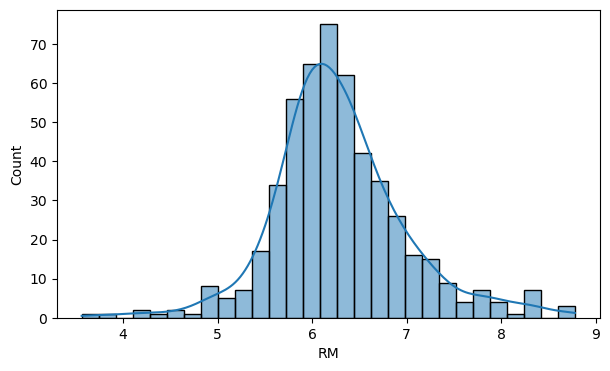

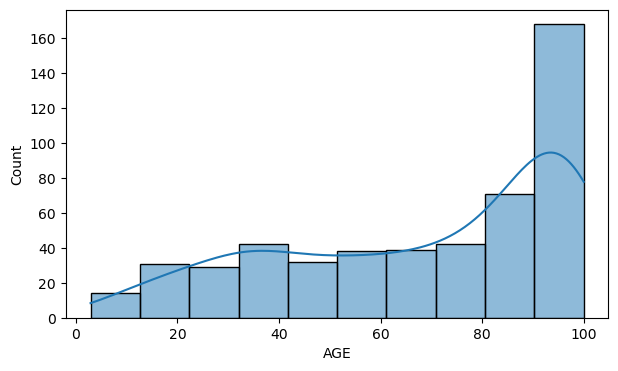

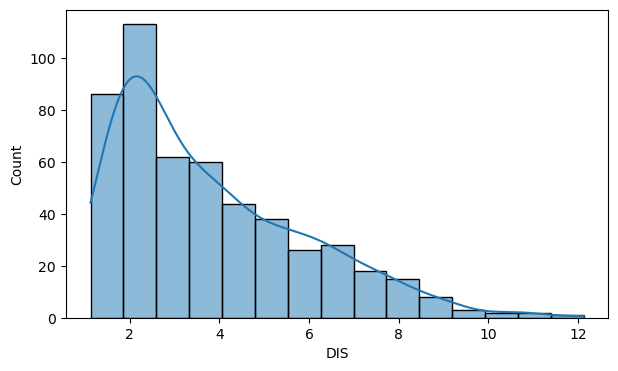

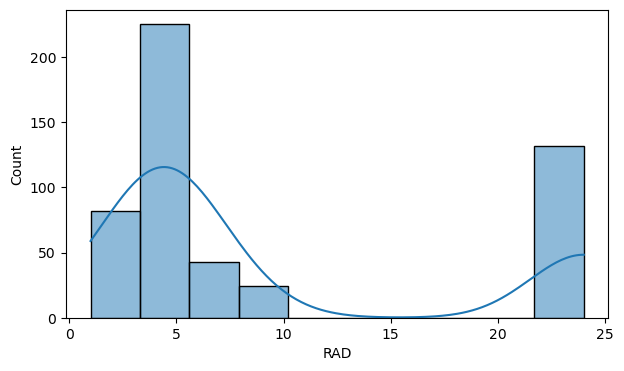

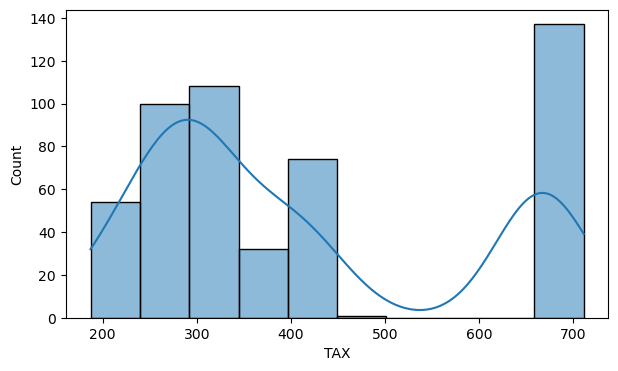

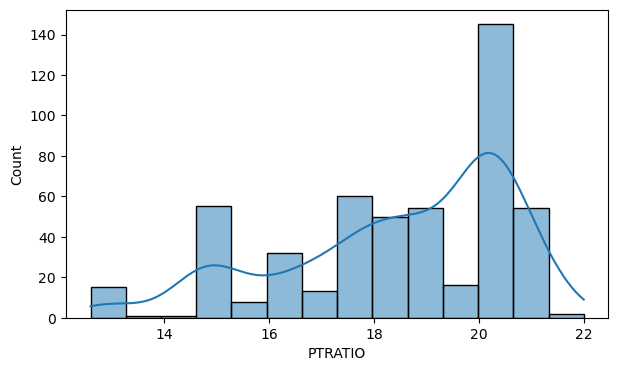

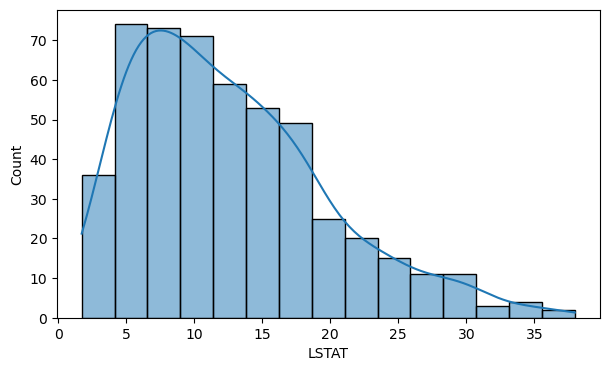

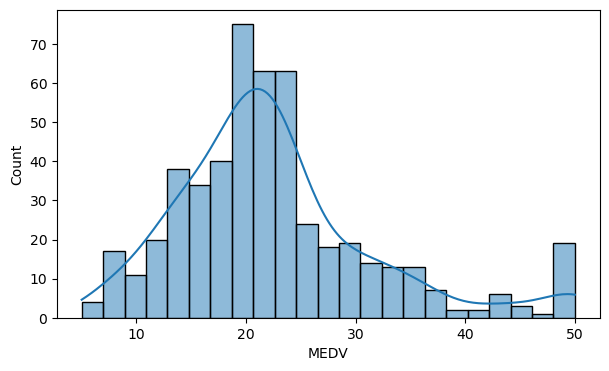

In [37]:
# Plotting all the columns to look at their distributions
for i in dataset.columns:
    
    plt.figure(figsize = (7, 4))
    
    sns.histplot(data = dataset, x = i, kde = True)
    
    plt.show()

In [38]:
# Observations:

# CRIM: Per capita crime rate by town
    # Heavily right skewed with most values being 0.
# ZN: Proportion of residential land zoned for lots over 25,000 sq.ft.
    # Most residential areas have 0 ZN, followed by a near uniform distribution from 10-100%
# INDUS: Proportion of non-retail business acres per town
    # Apears to be 2 peaks centered at 5% and 17%.
# CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
    # Very few houses tract river
# NOX: Nitric Oxide concentration (parts per 10 million)
    # Right skewed
# RM: The average number of rooms per dwelling
    # Reletively normal distribution around 6.2
# AGE: Proportion of owner-occupied units built before 1940
    # Heavily left-skewed, suggesting most hases are older
# DIS: Weighted distances to five Boston employment centers
    # Heavily right-skewed
# RAD: Index of accessibility to radial highways
    # Reiterrates our above observation, likelke two cathegories of houses (rural and urban).
# TAX: Full-value property-tax rate per 10,000 dollars
    # Again looks like a similar representation to RAD of two cathegories of houses (rural and urban).
# PTRATIO: Pupil-teacher ratio by town
    # Left-skewed
# LSTAT: % lower status of the population
    # Right-skewed suggesting there are fewer overall lower socio-economic people.
# MEDV: Median value of owner-occupied homes in 1000 dollars
    # Slightly skewed. As this is our dependent variable will need to take action to normalize it.
# Least squares regression models assume the residuals are normal, and a non-normal dependent variable will produce non-normal residual 
# errors. Therefore, as the dependent variable is sightly skewed, we need to apply a log transformation on the 'MEDV' column and check 
# the distribution of the transformed column.

In [39]:
# Import library for preparing data spliting
from sklearn.model_selection import train_test_split

In [40]:
# splitting the data in 70:30 ratio of train to test data
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.25)

In [49]:
x_test.shape, y_test.shape

((127, 12), (127,))

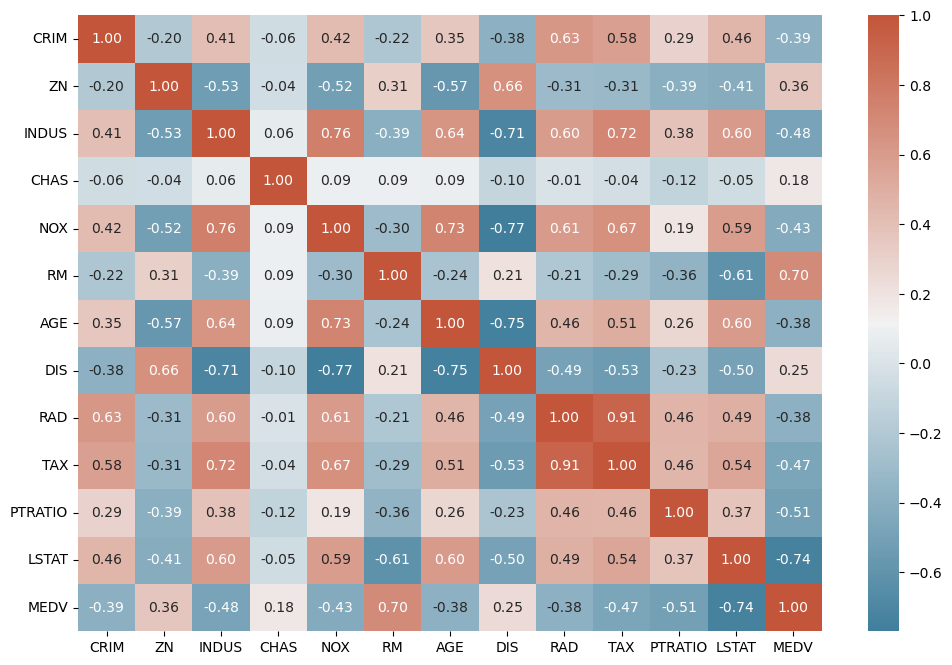

In [50]:
# Bivariate Analysis
# Check the correlation using heatmap

plt.figure(figsize = (12, 8))

cmap = sns.diverging_palette(230, 20, as_cmap = True)

sns.heatmap(dataset.corr(), annot = True, fmt = '.2f', cmap = cmap)

plt.show()

In [ ]:
# Observations:

# Correlations involving dependent variable:

# The highest possitive correlating feature for MEDV_log is RM(average number of rooms).
    # This makes sense as more rooms typically indicates a larger home
# The highest negative correlating feature for MEDV_log is LSTAT(% lower status of the population).
    # This makes sense as cities often have lower income areas.
# It is note worthy that 8/12 of our features have negative correlations with MEDV_log, this means most of them are measuring 
# undesirable factors.


# Other strong correlations (>= 0.7 or <= -0.7) not involving our dependent variable:

# Positive Correlation between NOX and INDUS, makes sense as more industrial areas would produces more Nitric Oxide
# Positive Correlation between NOX and AGE, perhaps indicating that the older areas are more industrialized?
# Neggative Correlation between DIS and INDUS, DIS and NOX, DIS and AGE.
    # Distance to Boston employment centers seems to indicate a more modern area seperate from the older industrial areas that produce 
    # more nitric oxide. 
# Positive Correlation between TAX and INDUS
# Very high Positive Correlation between TAX and RAD

In [51]:
# Visualizing the relationship between the features having significant correlations (>= 0.7 or <= -0.7)

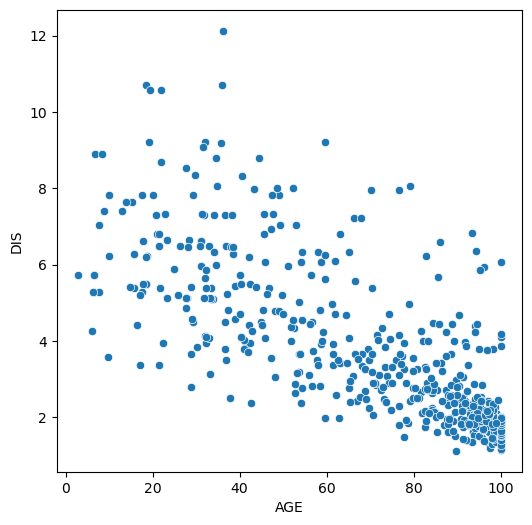

In [52]:
# Scatterplot to visualize the relationship between AGE and DIS
plt.figure(figsize = (6, 6))

sns.scatterplot(x = 'AGE', y = 'DIS', data = dataset)

plt.show()

In [53]:
# Observations:

# The distance of the houses to the Boston employment centers appears to decrease moderately as the proportion of old houses 
# increases in the town. The Boston employment centers may be located in the established towns where the proportion of
# owner-occupied units built is comparatively high.

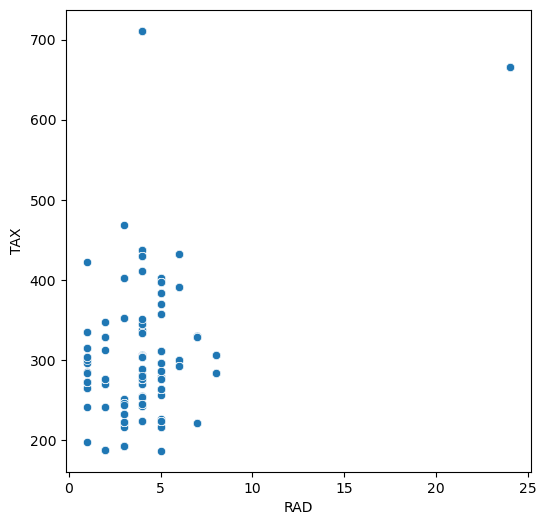

In [54]:
# Scatterplot to visulaize the relationship between RAD and TAX
plt.figure(figsize = (6, 6))

sns.scatterplot(x = 'RAD', y = 'TAX', data = dataset)

plt.show()

In [55]:
# Observations:

# The correlation between RAD and TAX is very high. But no trend is visible between the two variables.
# The strong correlation might be due to outliers.

In [67]:
# Remove the data corresponding to high tax rate
dataset1 = dataset[dataset['TAX'] < 600]

# Import the required function
from scipy.stats import pearsonr

# Calculate the correlation
print('The correlation between TAX and RAD is', pearsonr(dataset1['TAX'], dataset1['RAD'])[0])

The correlation between TAX and RAD is 0.249757313314292


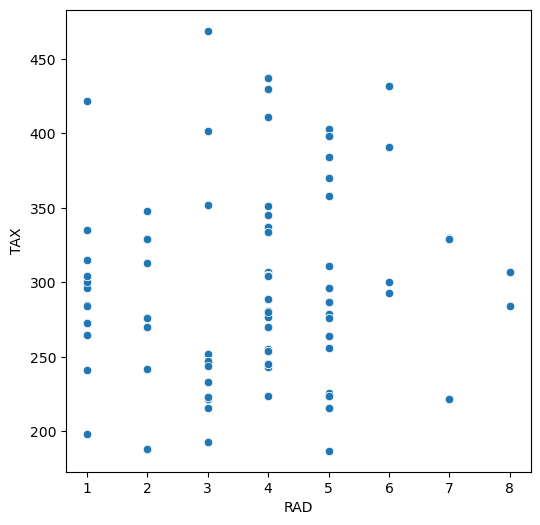

In [68]:
# Scatterplot to visulaize the relationship between RAD and TAX after outlier removal
plt.figure(figsize = (6, 6))

sns.scatterplot(x = 'RAD', y = 'TAX', data = dataset1)

plt.show()

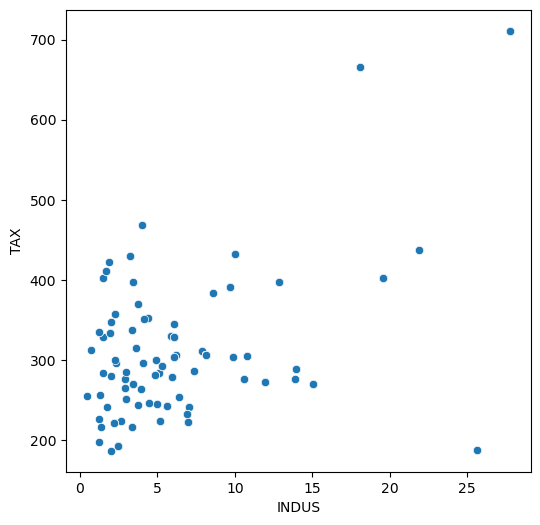

In [56]:
# Scatterplot to visualize the relationship between INDUS and TAX
plt.figure(figsize = (6, 6))

sns.scatterplot(x = 'INDUS', y = 'TAX', data = dataset)

plt.show()

In [57]:
# Observations:

# The tax rate appears to increase with an increase in the proportion of non-retail business acres per town. 
# This might be due to the reason that the variables TAX and INDUS are related with a third variable.

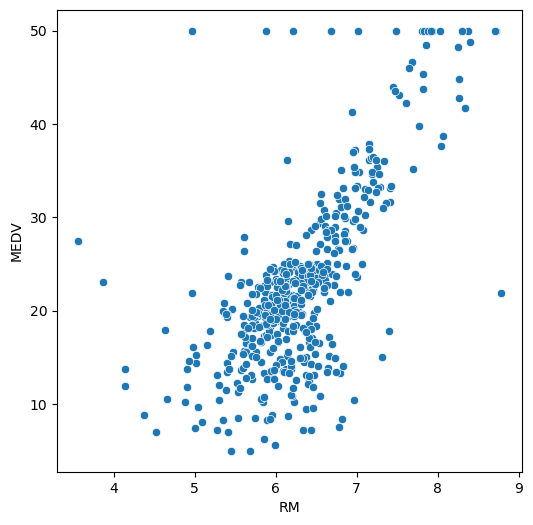

In [58]:
# Scatterplot to visulaize the relationship between RM and MEDV
plt.figure(figsize = (6, 6))

sns.scatterplot(x = 'RM', y = 'MEDV', data = dataset)

plt.show()

In [59]:
# Observations:

# The price of the house seems to increase as the value of RM increases. This is expected as the price is generally higher for more rooms.

# There are a few outliers in a horizontal line as the MEDV value seems to be capped at 50.

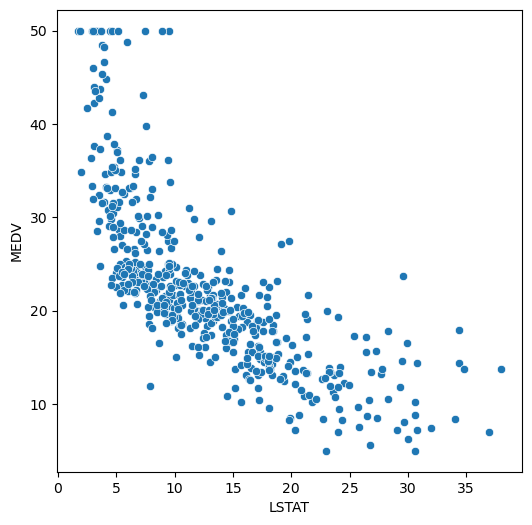

In [60]:
# Scatterplot to visulaize the relationship between LSTAT and MEDV
plt.figure(figsize = (6, 6))

sns.scatterplot(x = 'LSTAT', y = 'MEDV', data = dataset)

plt.show()

In [61]:
# Observations:

# The price of the house tends to decrease with an increase in LSTAT. This is also possible as the house price is lower in areas where 
# lower status people live.

# There are few outliers and the data seems to be capped at 50.

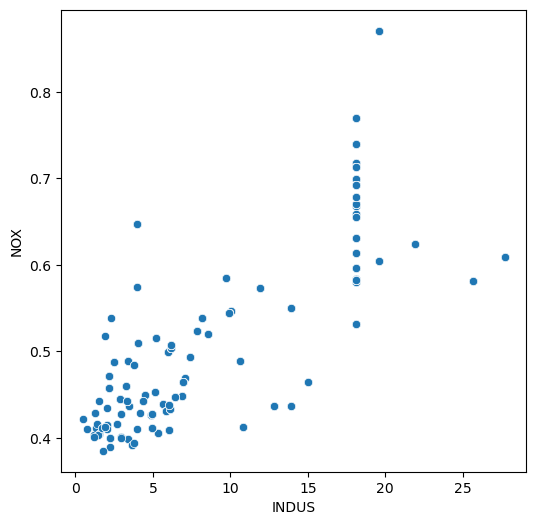

In [62]:
# Scatterplot to visualize the relationship between INDUS and NOX
plt.figure(figsize = (6, 6))

sns.scatterplot(x = 'INDUS', y = 'NOX', data = dataset)

plt.show()

In [63]:
# Observations:

# Nitric Oxide does seem to increase with industrial areas
# No obviouse outliers present

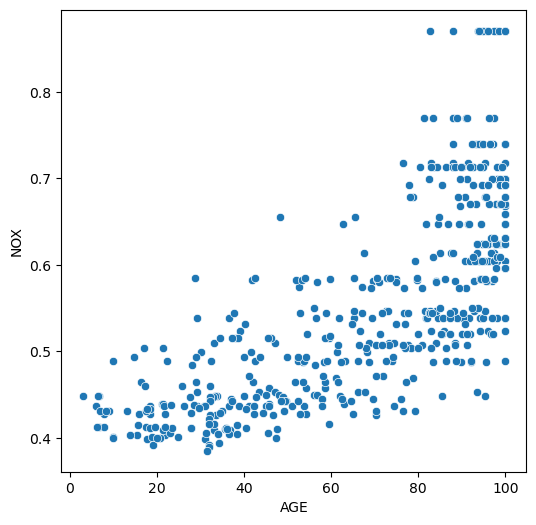

In [64]:
# Scatterplot to visualize the relationship between AGE and NOX
plt.figure(figsize = (6, 6))

sns.scatterplot(x = 'AGE', y = 'NOX', data = dataset)

plt.show()

In [65]:
# Observations:

# Slight increase in Nitric Oxide with age of the house, againg giving credence to the theory that those are more industrial areas
# Posiblibly a group of highest NOX values being outliers.

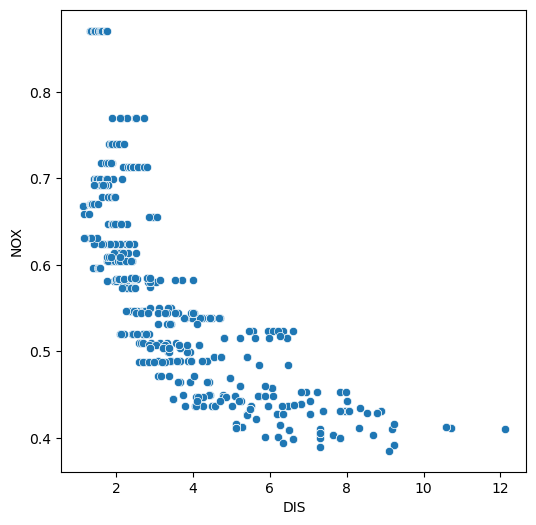

In [66]:
# Scatterplot to visualize the relationship between DIS and NOX
plt.figure(figsize = (6, 6))

sns.scatterplot(x = 'DIS', y = 'NOX', data = dataset)

plt.show()

In [ ]:
# Observations:

# Nitric Oxide strongly decreases with distance to employment centers. Possible that those centers are located in newer less industruse 
# parts of Boston.


# LSTAT and RM have a linear relationship with the dependent variable MEDV. Also, there are significant relationships among few 
# independent variables, which is not desirable for a linear regression model.